# Supervised Learning: Klasifikasi Stunting Balita Berdasarkan Antropometri dan Analisis Data Leakage

In [1]:
# Mengimpor pustaka utama untuk analisis data, pemodelan, evaluasi, penyeimbangan kelas, dan interpretasi model
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Mengatur resolusi grafik matplotlib secara global ke 300 DPI untuk standar publikasi
mpl.rcParams['figure.dpi'] = 300
sns.set_theme(style='whitegrid')
print("Seluruh pustaka klasifikasi berhasil diimpor dengan konfigurasi visualisasi 300 DPI!")

Seluruh pustaka klasifikasi berhasil diimpor dengan konfigurasi visualisasi 300 DPI!


/home/haerulyudaaditiya/Downloads/exp/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Memuat Dataset Balita dan Tabel Referensi WHO
Kita memuat dataset status gizi balita serta tabel parameter LMS WHO untuk laki-laki dan perempuan.

In [2]:
# Memuat dataset utama
df_ml = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/stunting_wasting_dataset.csv')

# Memuat tabel referensi standar WHO Z-scores
who_lhfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_lhfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')

# Menstandarkan nama kolom pertama menjadi 'c' (mewakili Age/Month)
who_lhfa_boys = who_lhfa_boys.rename(columns={who_lhfa_boys.columns[0]: 'c'})
who_lhfa_girls = who_lhfa_girls.rename(columns={who_lhfa_girls.columns[0]: 'c'})
who_wfa_boys = who_wfa_boys.rename(columns={who_wfa_boys.columns[0]: 'c'})
who_wfa_girls = who_wfa_girls.rename(columns={who_wfa_girls.columns[0]: 'c'})

print(f"Dataset balita berhasil dimuat. Total baris: {df_ml.shape[0]}, Total kolom: {df_ml.shape[1]}")

Dataset balita berhasil dimuat. Total baris: 100000, Total kolom: 6


## 2. Inspeksi Data Awal (*Data Inspection*)
Menampilkan 5 baris pertama untuk melihat contoh isi dataset.

In [3]:
df_ml.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


### 2.1 Informasi Tipe Data dan Kolom
Menampilkan tipe data tiap kolom dan jumlah data terisi.

In [4]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Jenis Kelamin      100000 non-null  str    
 1   Umur (bulan)       100000 non-null  int64  
 2   Tinggi Badan (cm)  100000 non-null  float64
 3   Berat Badan (kg)   100000 non-null  float64
 4   Stunting           100000 non-null  str    
 5   Wasting            100000 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 4.6 MB


### 2.2 Deskripsi Statistik Dataset
Menampilkan ringkasan statistik (rata-rata, standar deviasi, nilai minimum dan maksimum) untuk variabel numerik.

In [5]:
df_ml.describe()

,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg)
count,100000.000000,100000.000000,100000.000000
mean,11.992580,73.132657,9.259256
std,7.199671,11.360846,3.300780
min,0.000000,42.600000,1.000000
25%,6.000000,65.500000,6.900000
50%,12.000000,74.200000,9.200000
75%,18.000000,81.400000,11.700000
max,24.000000,97.600000,17.200000


### 2.3 Pengecekan Nilai Kosong dan Duplikat
Menghitung jumlah data kosong dan baris duplikat.

In [6]:
print("Nilai kosong:")
print(df_ml.isnull().sum())
print(f"\nJumlah data duplikat: {df_ml.duplicated().sum()}")

Nilai kosong:
Jenis Kelamin        0
Umur (bulan)         0
Tinggi Badan (cm)    0
Berat Badan (kg)     0
Stunting             0
Wasting              0
dtype: int64

Jumlah data duplikat: 7308


### 2.4 Inspeksi Tabel Standar WHO LMS
Menampilkan struktur tabel parameter LMS (L: skewness, M: median, S: koefisien variasi) standar WHO yang digunakan sebagai dasar kalkulasi Z-score.

In [7]:
print("Tabel WHO Length-for-Age (Laki-laki) 5 baris pertama:")
who_lhfa_boys.head()

Tabel WHO Length-for-Age (Laki-laki) 5 baris pertama:


,c,L,M,S,SD,SD3neg,SD2neg,SD1neg,SD0,SD1,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,0,1,49.8842,0.03795,1.8931,44.2,46.1,48.0,49.9,51.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,54.7244,0.03557,1.9465,48.9,50.8,52.8,54.7,56.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,58.4249,0.03424,2.0005,52.4,54.4,56.4,58.4,60.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,61.4292,0.03328,2.0444,55.3,57.3,59.4,61.4,63.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,63.8860,0.03257,2.0808,57.6,59.7,61.8,63.9,66.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Analisis Eksplorasi Data (EDA) - Resolusi Tinggi 300 DPI
Kita menganalisis distribusi target status stunting dan korelasi antar variabel fisik.

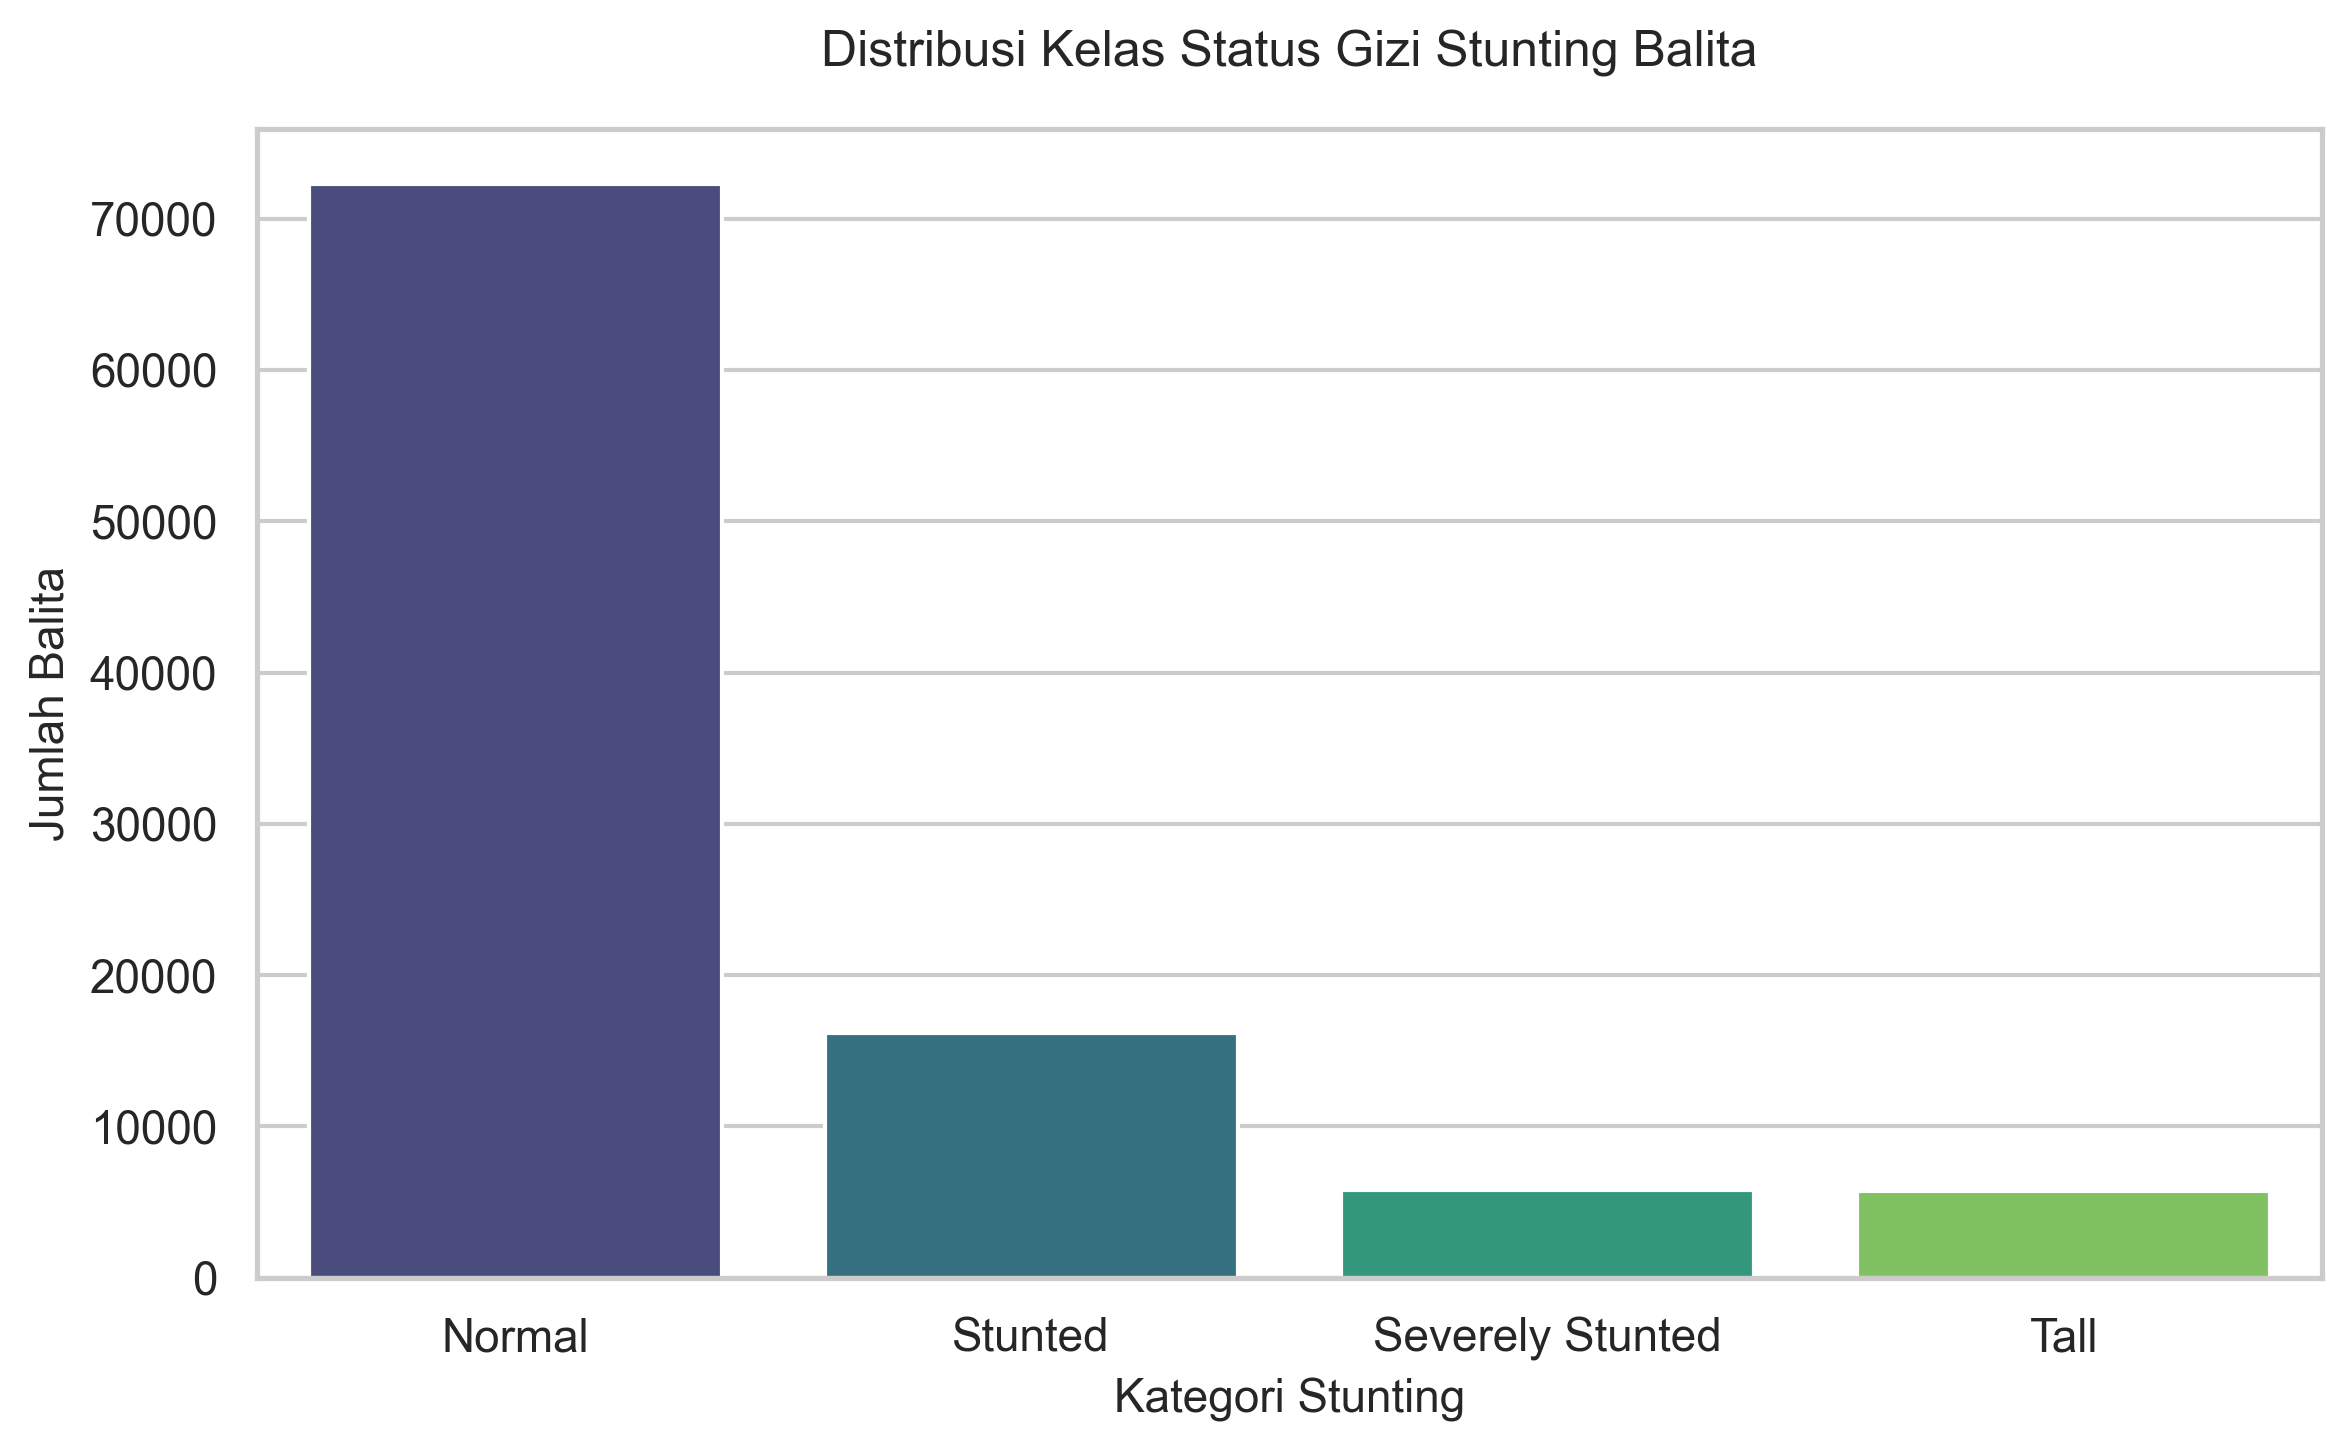

In [8]:
# 3.1 Distribusi Kelas Target Stunting
plt.figure(figsize=(8, 5))
sns.countplot(data=df_ml, x='Stunting', order=['Normal', 'Stunted', 'Severely Stunted', 'Tall'], palette='viridis')
plt.title('Distribusi Kelas Status Gizi Stunting Balita', fontsize=12, pad=15)
plt.xlabel('Kategori Stunting', fontsize=11)
plt.ylabel('Jumlah Balita', fontsize=11)
plt.tight_layout()
plt.savefig('results/distribusi_kelas_stunting.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 Kurva Pertumbuhan Fisik: Tinggi Badan vs Umur
Scatter plot memperlihatkan perbedaan tinggi badan anak berdasarkan kategori usia dan status gizi.

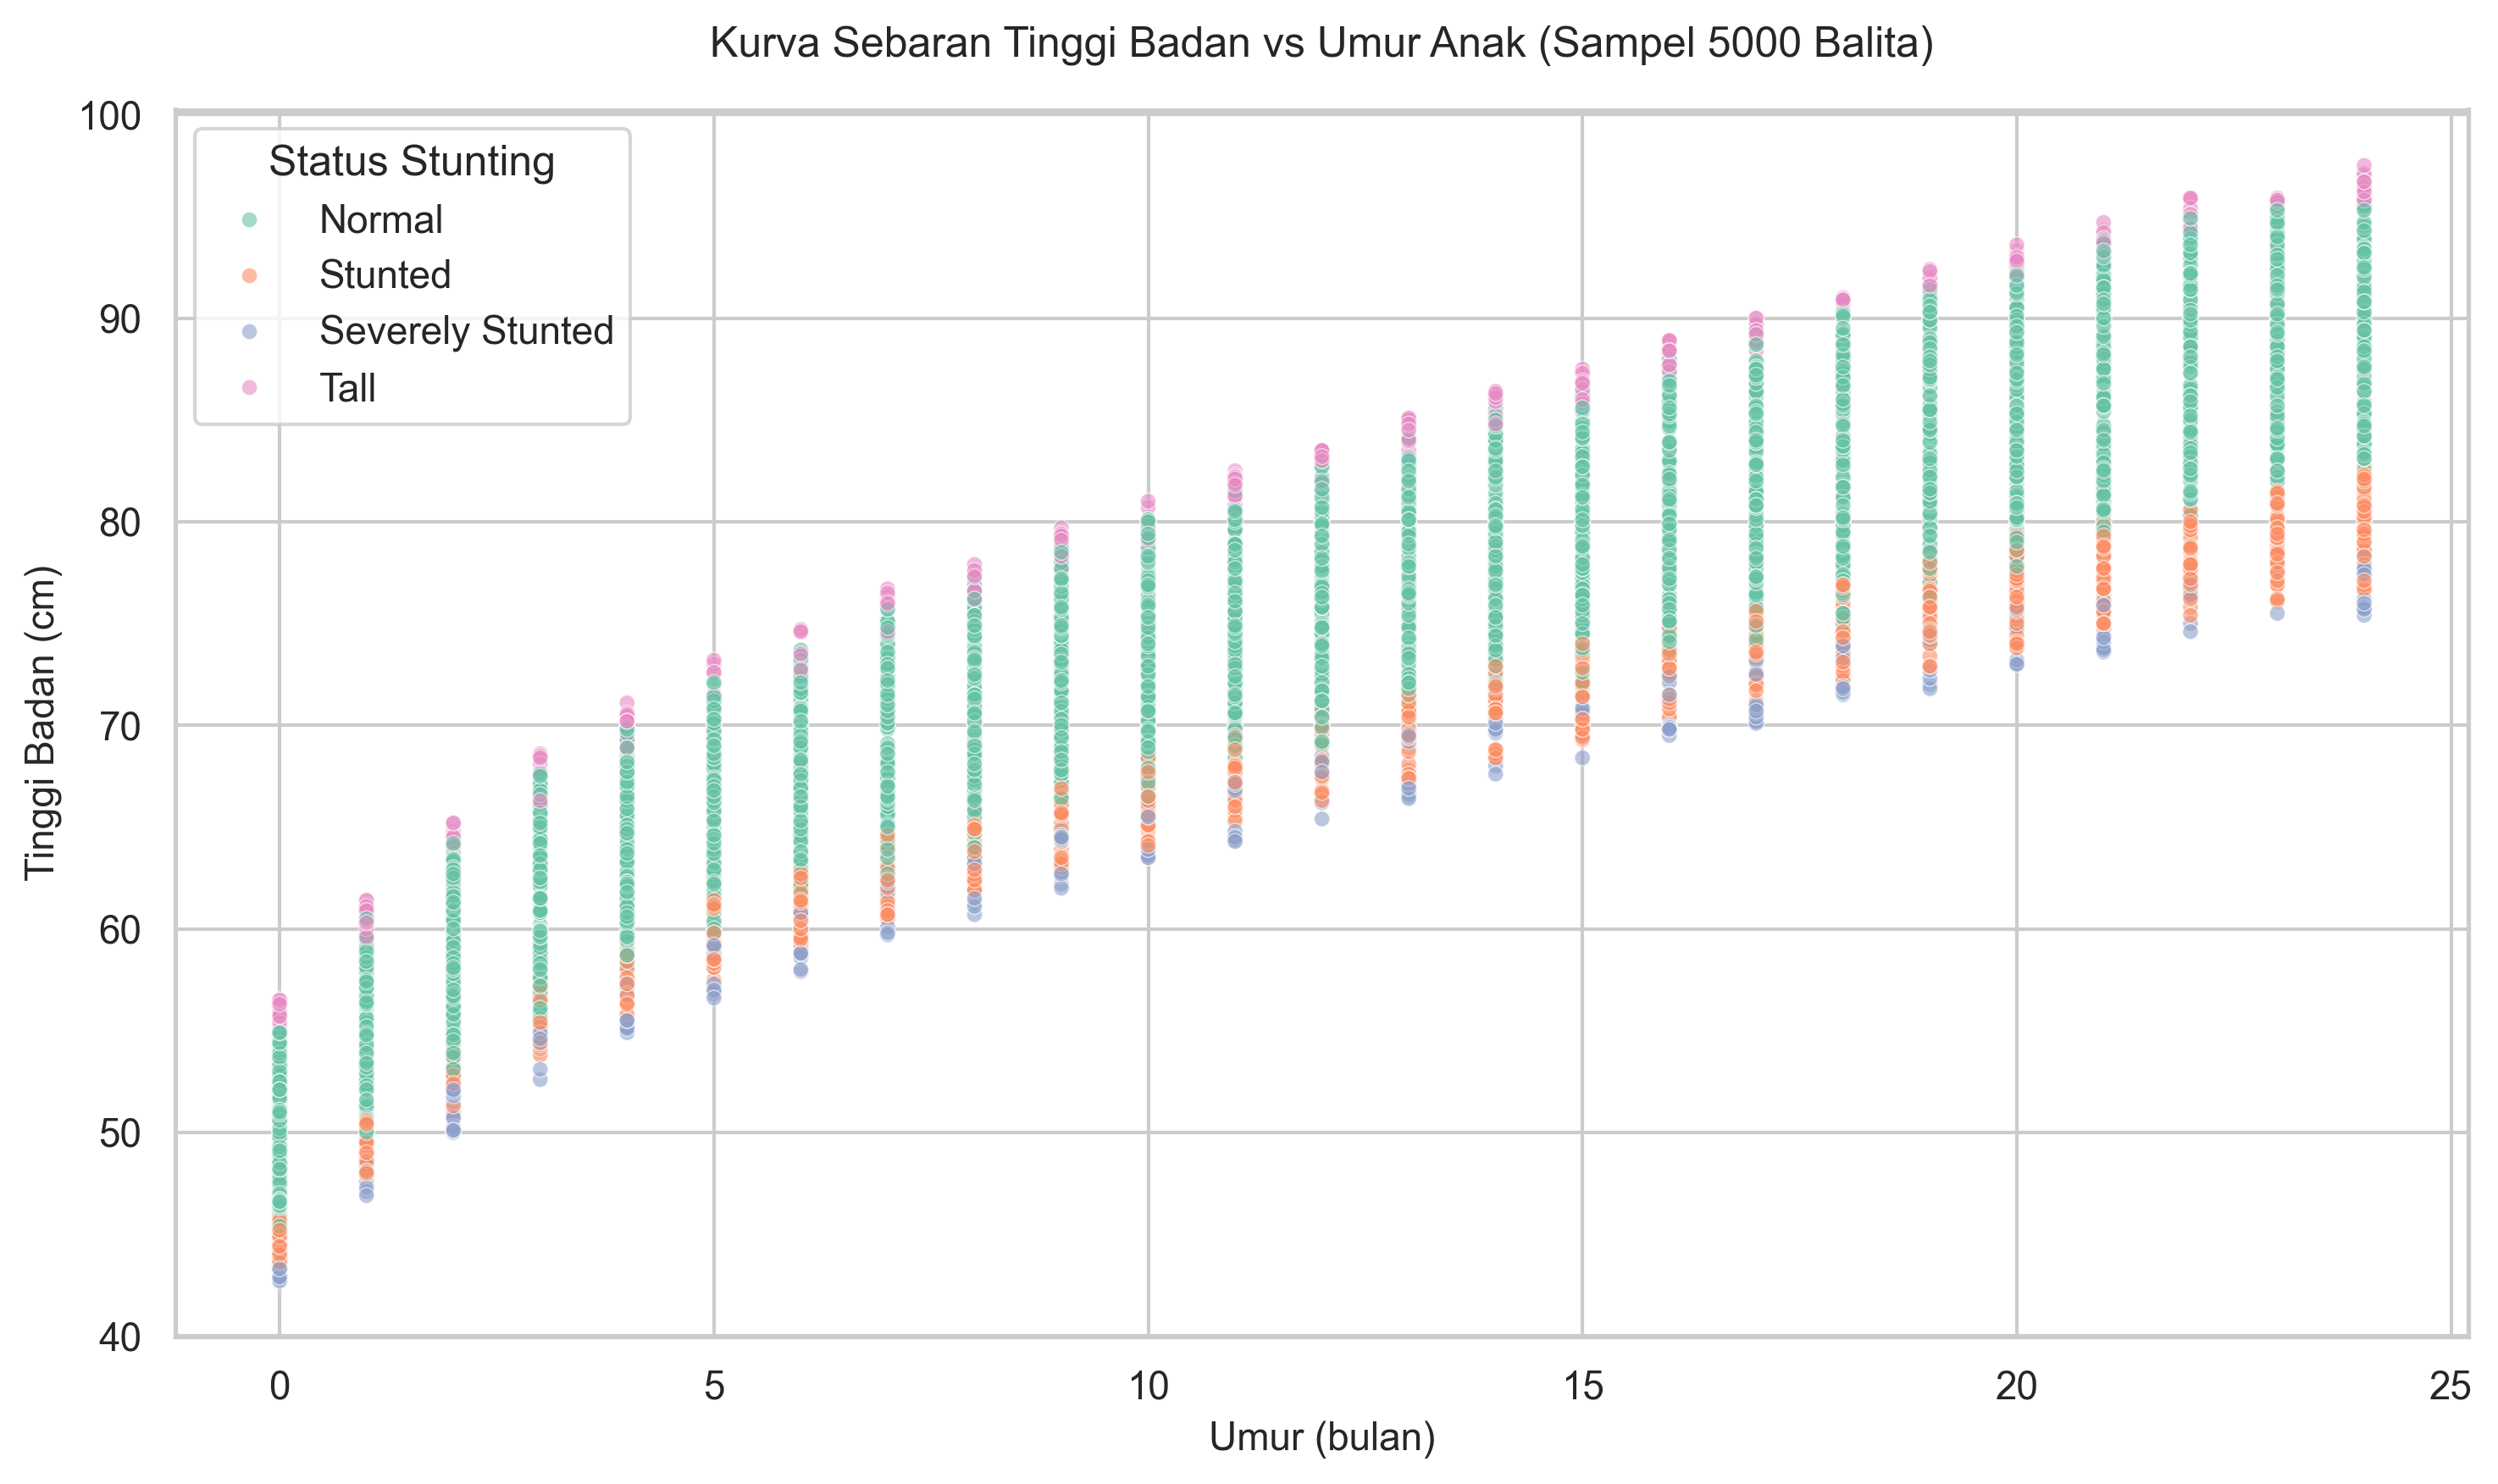

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml.sample(5000, random_state=42),
    x='Umur (bulan)',
    y='Tinggi Badan (cm)',
    hue='Stunting',
    hue_order=['Normal', 'Stunted', 'Severely Stunted', 'Tall'],
    palette='Set2',
    alpha=0.6,
    s=20
)
plt.title('Kurva Sebaran Tinggi Badan vs Umur Anak (Sampel 5000 Balita)', fontsize=12, pad=15)
plt.xlabel('Umur (bulan)', fontsize=11)
plt.ylabel('Tinggi Badan (cm)', fontsize=11)
plt.legend(title='Status Stunting')
plt.tight_layout()
plt.savefig('results/sebaran_pertumbuhan_stunting.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Feature Engineering: Ekstraksi Z-Score secara Klinis
Menggunakan rumus LMS WHO untuk menghitung nilai HAZ dan WAZ secara dinamis berdasarkan tabel referensi.

In [10]:
def compute_z_scores(df_main, df_who_lhfa, df_who_wfa):
    original_index = df_main.index

    # 1. HAZ
    df_merged = pd.merge(df_main, df_who_lhfa[['c', 'L', 'M', 'S']], left_on='Umur (bulan)', right_on='c', how='left')
    X_h = df_merged['Tinggi Badan (cm)']
    L_h = df_merged['L']
    M_h = df_merged['M']
    S_h = df_merged['S']
    df_merged['HAZ'] = (((X_h / M_h) ** L_h) - 1) / (L_h * S_h)
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    # 2. WAZ
    df_merged = pd.merge(df_merged, df_who_wfa[['c', 'L', 'M', 'S']], left_on='Umur (bulan)', right_on='c', how='left')
    X_w = df_merged['Berat Badan (kg)']
    L_w = df_merged['L']
    M_w = df_merged['M']
    S_w = df_merged['S']
    df_merged['WAZ'] = np.where(L_w == 0,
                                np.log(X_w / M_w) / S_w,
                                (((X_w / M_w) ** L_w) - 1) / (L_w * S_w))
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    df_merged.index = original_index
    return df_merged

df_boys = df_ml[df_ml['Jenis Kelamin'] == 'Laki-laki'].copy()
df_girls = df_ml[df_ml['Jenis Kelamin'] == 'Perempuan'].copy()

df_boys_enriched = compute_z_scores(df_boys, who_lhfa_boys, who_wfa_boys)
df_girls_enriched = compute_z_scores(df_girls, who_lhfa_girls, who_wfa_girls)

df_final = pd.concat([df_boys_enriched, df_girls_enriched]).sort_index()
df_final.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting,HAZ,WAZ
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight,3.033495,1.587105
1,Laki-laki,20,77.7,8.5,Stunted,Underweight,-2.309778,-2.572957
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight,2.502858,1.077254
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight,-3.323558,3.790974
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight,-3.441070,3.690638


### 4.1 Pembagian Pipeline Eksperimen (Leaky vs Clean)
Kita menyusun variabel input dan target:
1. **Leaky Pipeline**: Memasukkan `HAZ` dan `WAZ` sebagai fitur input.
2. **Clean Pipeline**: Hanya menggunakan fitur antropometrik fisik mentah (`Jenis Kelamin`, `Umur (bulan)`, `Tinggi Badan (cm)`, `Berat Badan (kg)`).

In [11]:
# Label Encoding untuk Jenis Kelamin dan Target
gender_encoder = LabelEncoder()
df_final['Jenis Kelamin_Encoded'] = gender_encoder.fit_transform(df_final['Jenis Kelamin'])

stunting_encoder = LabelEncoder()
df_final['Stunting_Encoded'] = stunting_encoder.fit_transform(df_final['Stunting'])

# Definisikan Target
y = df_final['Stunting_Encoded']

# 1. Leaky Features
X_leaky = df_final[['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'HAZ', 'WAZ']]

# 2. Clean Features
X_clean = df_final[['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']]

print("Preprocessing data selesai!")

Preprocessing data selesai!


## 5. Implementasi Leaky Pipeline (Pembagian Uji Acak Tunggal)
Melatih model pada Leaky Pipeline untuk membuktikan bias kebocoran data.

In [12]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leaky, y, test_size=0.2, random_state=42)

models_leaky = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(random_seed=42, verbose=0)
}

f1_leaky = {}
print("Evaluasi Model pada Leaky Pipeline (Weighted F1):")
for name, model in models_leaky.items():
    model.fit(X_train_l, y_train_l)
    preds = model.predict(X_test_l)
    f1 = f1_score(y_test_l, preds, average='weighted')
    f1_leaky[name] = f1
    print(f"- {name} F1-Score: {f1:.6f}")

Evaluasi Model pada Leaky Pipeline (Weighted F1):
- Random Forest F1-Score: 1.000000
- Extra Trees F1-Score: 0.999550
- XGBoost F1-Score: 1.000000
- LightGBM F1-Score: 1.000000
- CatBoost F1-Score: 1.000000


## 6. Implementasi Clean Pipeline Teruji (Stratified 5-Fold CV & Class Weights)
Melatih model kembali menggunakan fitur bersih tanpa Z-score. Kita menerapkan **Stratified 5-Fold Cross Validation** untuk menguji stabilitas secara ilmiah, serta mengimplementasikan penanganan ketidakseimbangan kelas (*class weights*).

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_clean = {}
trained_clean_models = {}

print("Mengevaluasi Clean Pipeline menggunakan Stratified 5-Fold Cross Validation:")

for name in ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']:
    fold_scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean, y)):
        X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[test_idx]

        # Menginisialisasi model dengan penanganan imbalance
        if name == 'Random Forest':
            model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'Extra Trees':
            model = ExtraTreesClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'XGBoost':
            model = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
            w = compute_sample_weight(class_weight='balanced', y=y_tr)
            model.fit(X_tr, y_tr, sample_weight=w)
        elif name == 'LightGBM':
            model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
            model.fit(X_tr, y_tr)
        elif name == 'CatBoost':
            model = CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=0)
            model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        fold_scores.append(f1_score(y_val, preds, average='weighted'))

    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    f1_clean[name] = mean_f1

    # Latih model final pada seluruh data clean untuk deployment
    if name == 'XGBoost':
        final_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
        w_full = compute_sample_weight(class_weight='balanced', y=y)
        final_xgb.fit(X_clean, y, sample_weight=w_full)
        trained_clean_models['XGBoost'] = final_xgb

    print(f"- {name} Weighted F1-Score: {mean_f1:.6f} +/- {std_f1:.6f}")

Mengevaluasi Clean Pipeline menggunakan Stratified 5-Fold Cross Validation:
- Random Forest Weighted F1-Score: 0.999800 +/- 0.000084
- Extra Trees Weighted F1-Score: 0.998509 +/- 0.000231
- XGBoost Weighted F1-Score: 0.987701 +/- 0.000425
- LightGBM Weighted F1-Score: 0.986230 +/- 0.000966
- CatBoost Weighted F1-Score: 0.964969 +/- 0.003603


## 7. Perbandingan Visual Dampak Data Leakage (300 DPI)
Visualisasi dampak data leakage pada model klasifikasi.

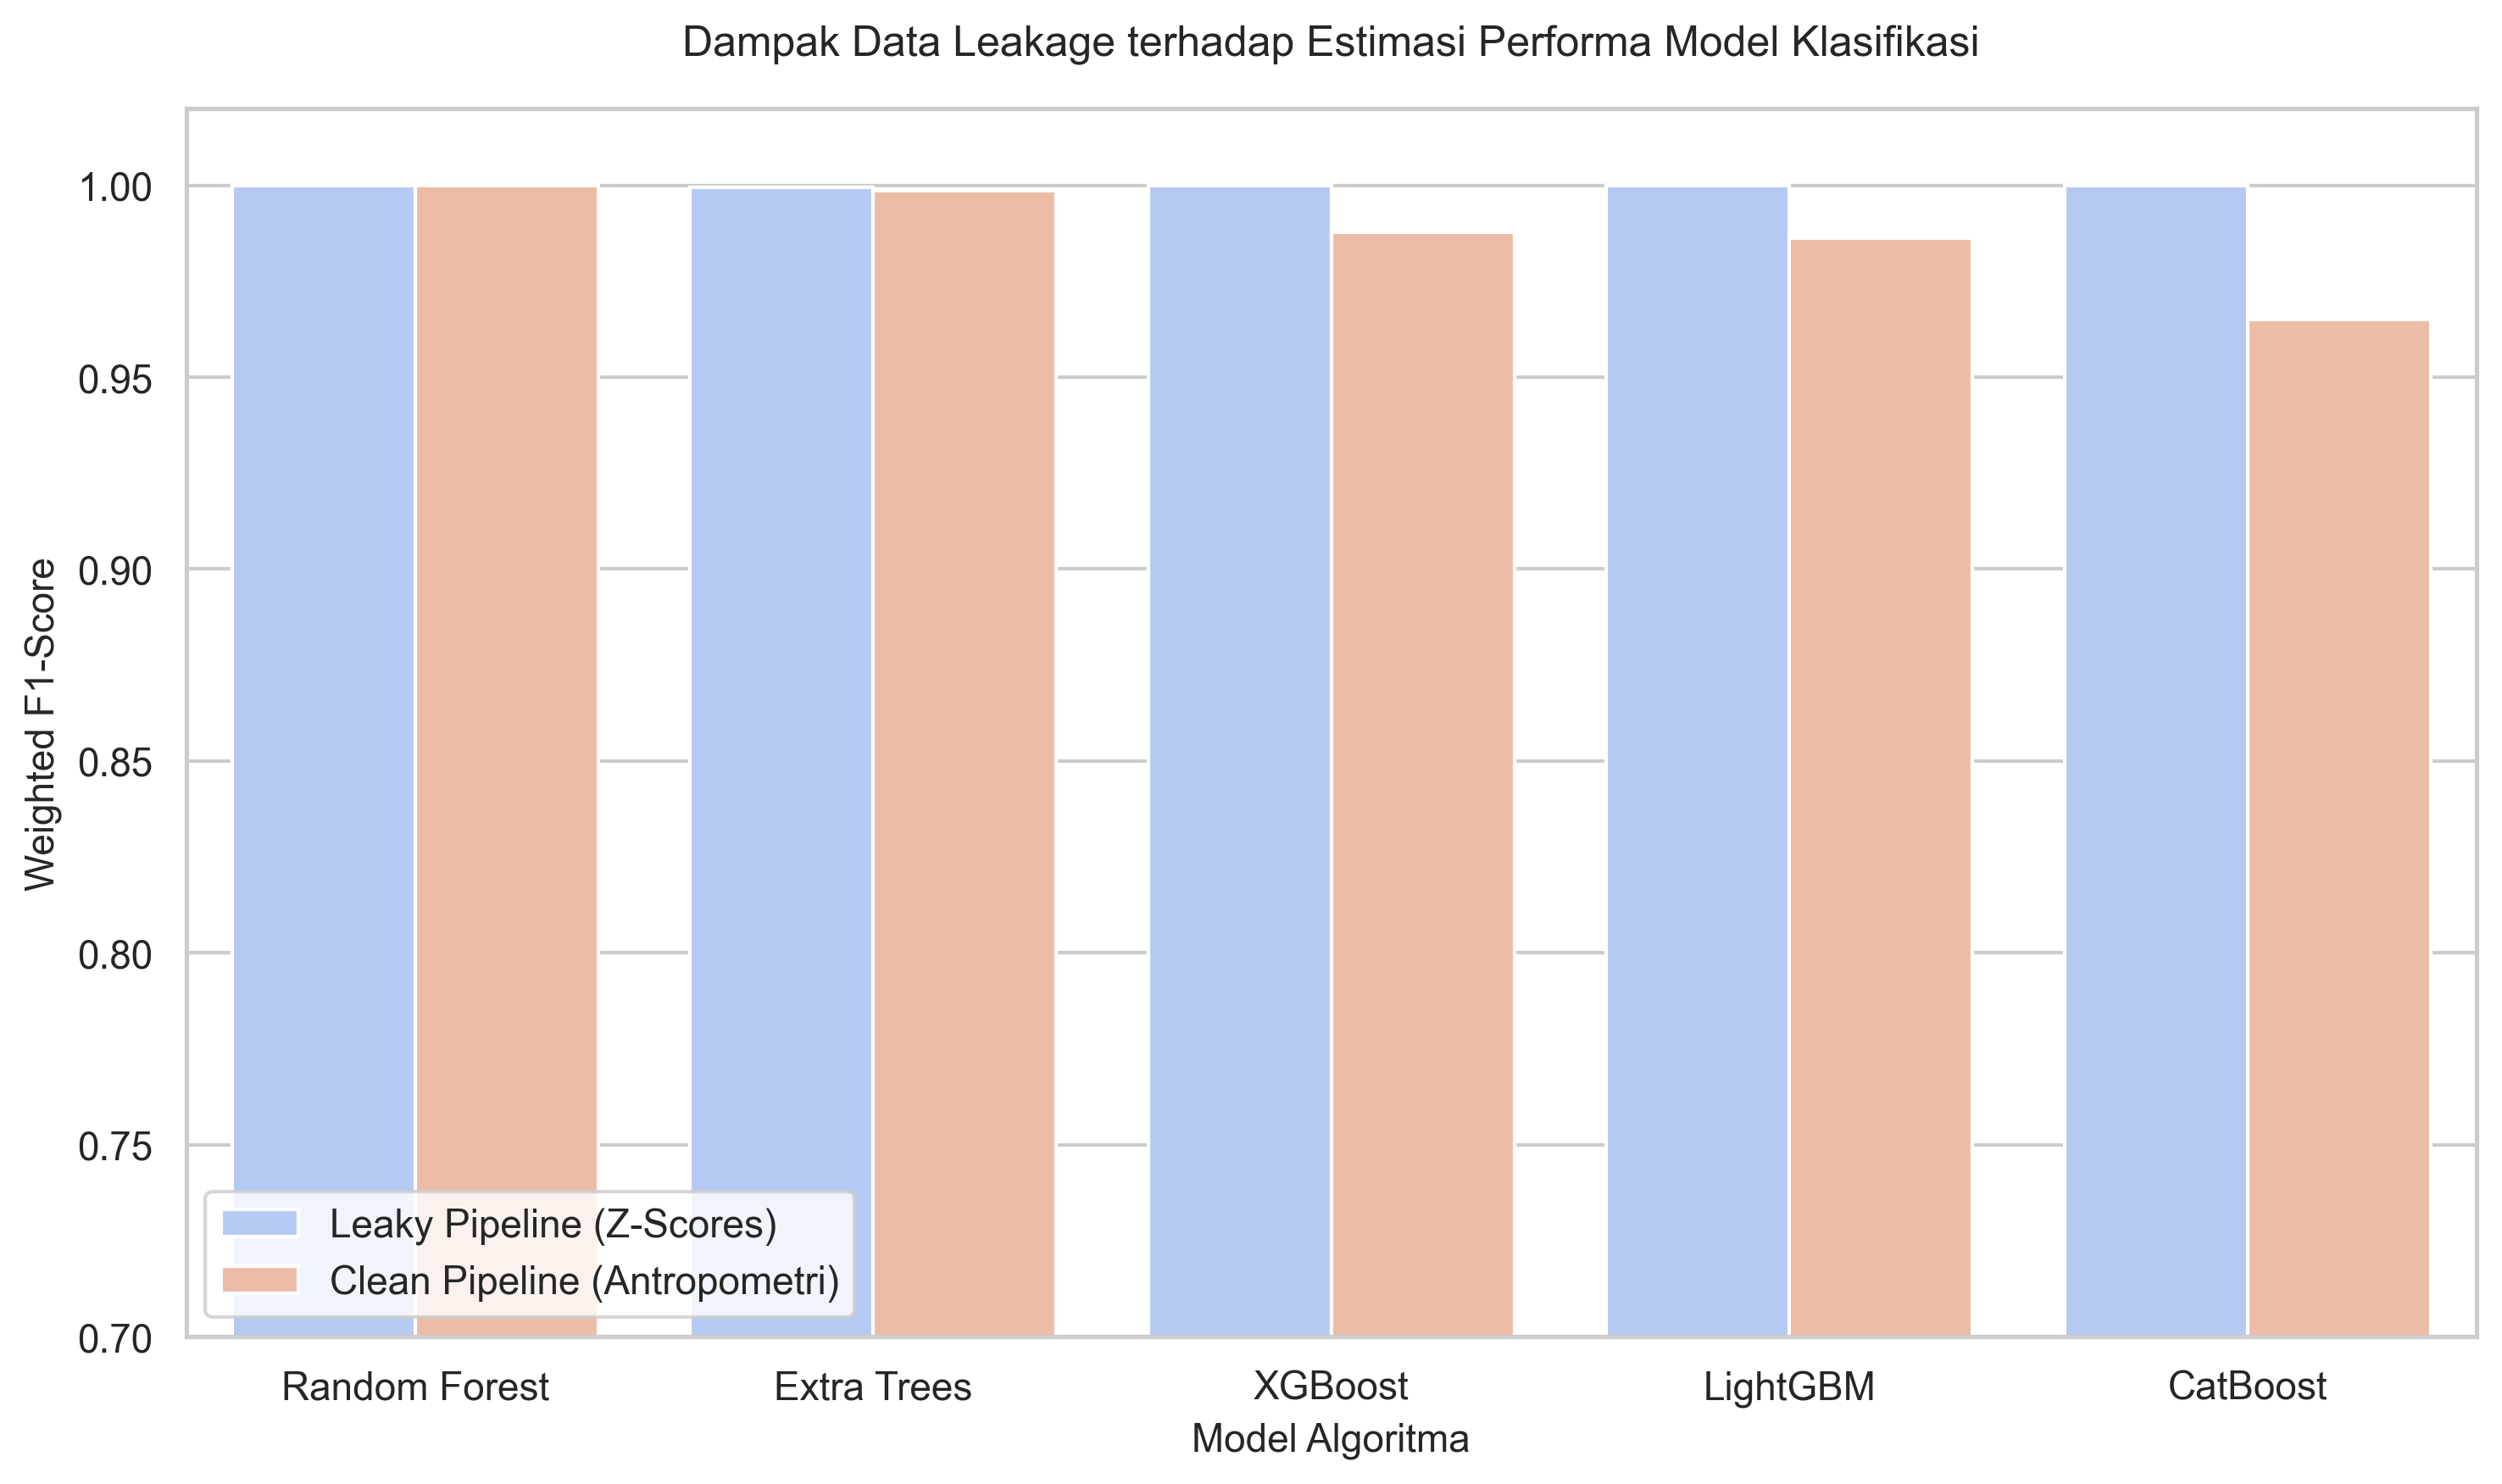

In [14]:
df_compare = pd.DataFrame({
    'Model': list(f1_leaky.keys()) * 2,
    'F1-Score': list(f1_leaky.values()) + list(f1_clean.values()),
    'Pipeline': ['Leaky Pipeline (Z-Scores)'] * 5 + ['Clean Pipeline (Antropometri)'] * 5
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df_compare, x='Model', y='F1-Score', hue='Pipeline', palette='coolwarm')
plt.title('Dampak Data Leakage terhadap Estimasi Performa Model Klasifikasi', fontsize=12, pad=15)
plt.xlabel('Model Algoritma', fontsize=11)
plt.ylabel('Weighted F1-Score', fontsize=11)
plt.ylim(0.7, 1.02)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('results/perbandingan_data_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Analisis Detail Model Bersih Terbaik (XGBoost)
Menampilkan classification report lengkap untuk model XGBoost pada Clean Pipeline.

In [15]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)
best_model = trained_clean_models['XGBoost']
clean_preds = best_model.predict(X_test_c)

print("Classification Report XGBoost (Clean Pipeline):")
print(classification_report(y_test_c, clean_preds, target_names=stunting_encoder.classes_))

Classification Report XGBoost (Clean Pipeline):
                  precision    recall  f1-score   support

          Normal       1.00      0.99      0.99     14406
Severely Stunted       0.95      1.00      0.97      1146
         Stunted       0.98      0.98      0.98      3292
            Tall       0.92      1.00      0.96      1156

        accuracy                           0.99     20000
       macro avg       0.96      0.99      0.98     20000
    weighted avg       0.99      0.99      0.99     20000



### 8.1 Visualisasi Confusion Matrix XGBoost (300 DPI)
Confusion matrix menampilkan perbandingan aktual vs prediksi kelas gizi buruk balita.

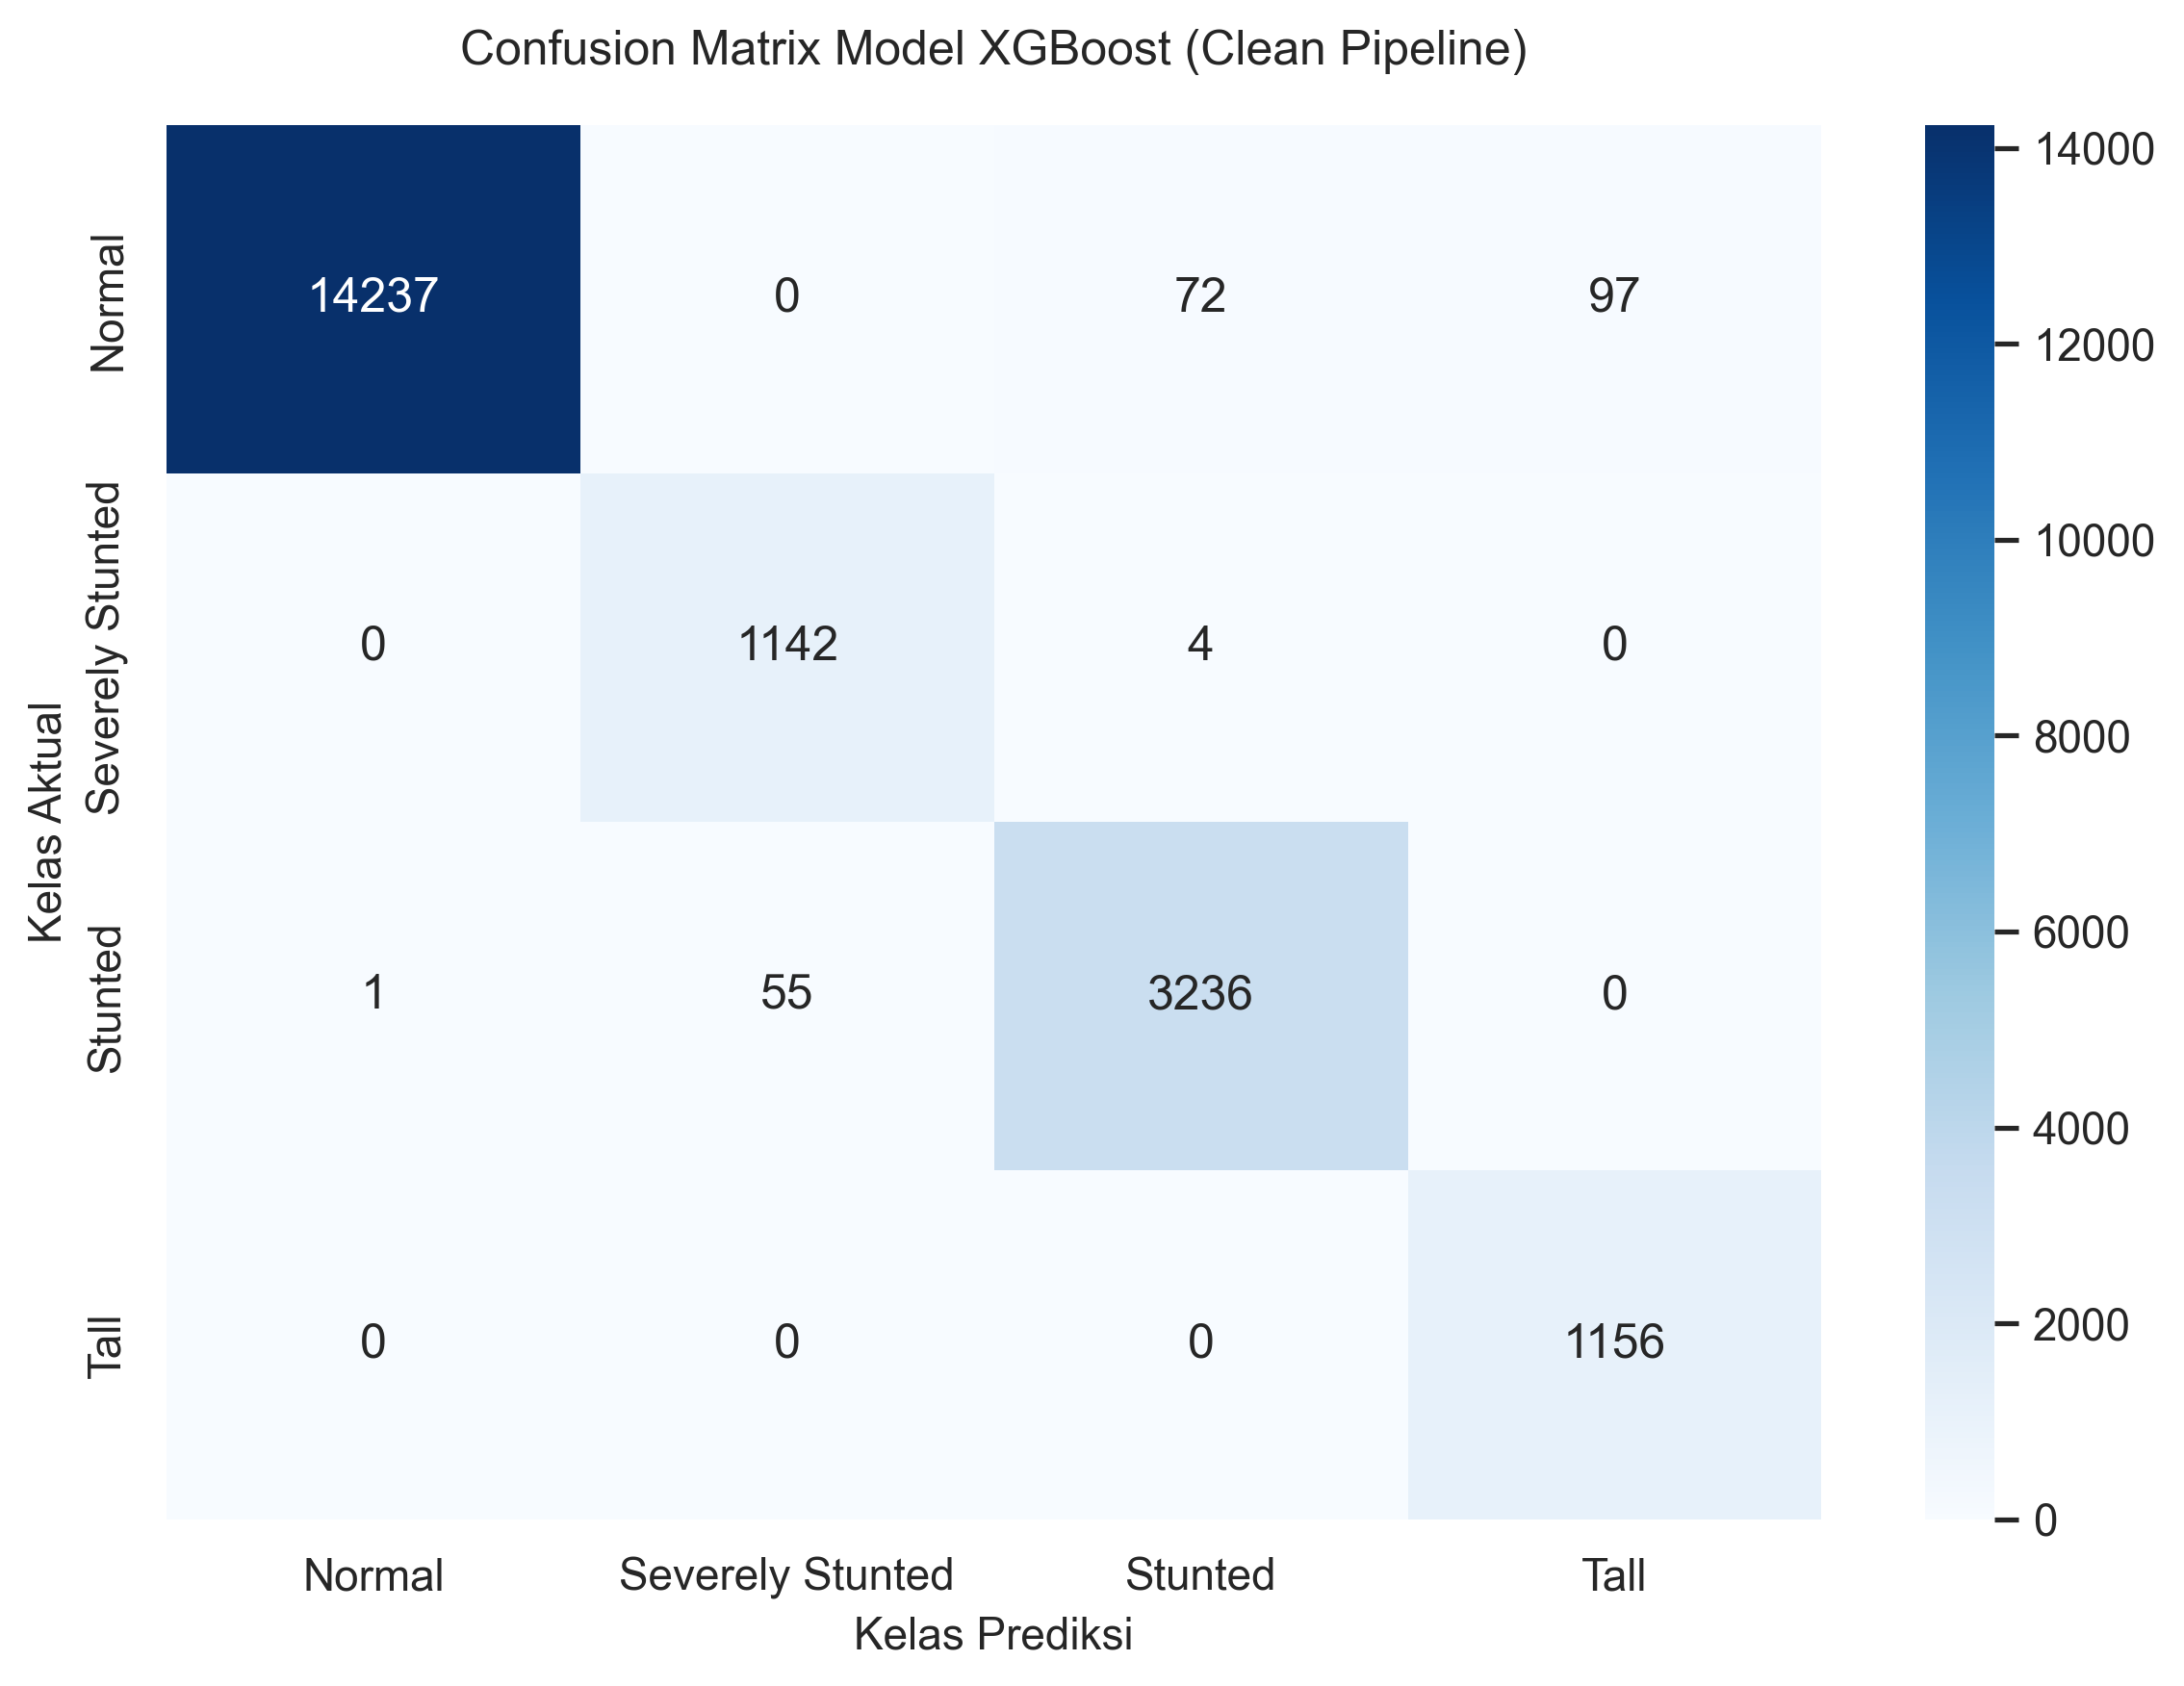

In [16]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, clean_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stunting_encoder.classes_,
            yticklabels=stunting_encoder.classes_)
plt.title('Confusion Matrix Model XGBoost (Clean Pipeline)', fontsize=12, pad=15)
plt.xlabel('Kelas Prediksi', fontsize=11)
plt.ylabel('Kelas Aktual', fontsize=11)
plt.tight_layout()
plt.savefig('results/confusion_matrix_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Interpretasi Pemodelan Klinis Menggunakan SHAP
Menggunakan penjelasan model global dan penjelasan lokal (Waterfall Plot) untuk menerjemahkan logika prediksi model secara medis.

Indeks kelas Stunted: 2


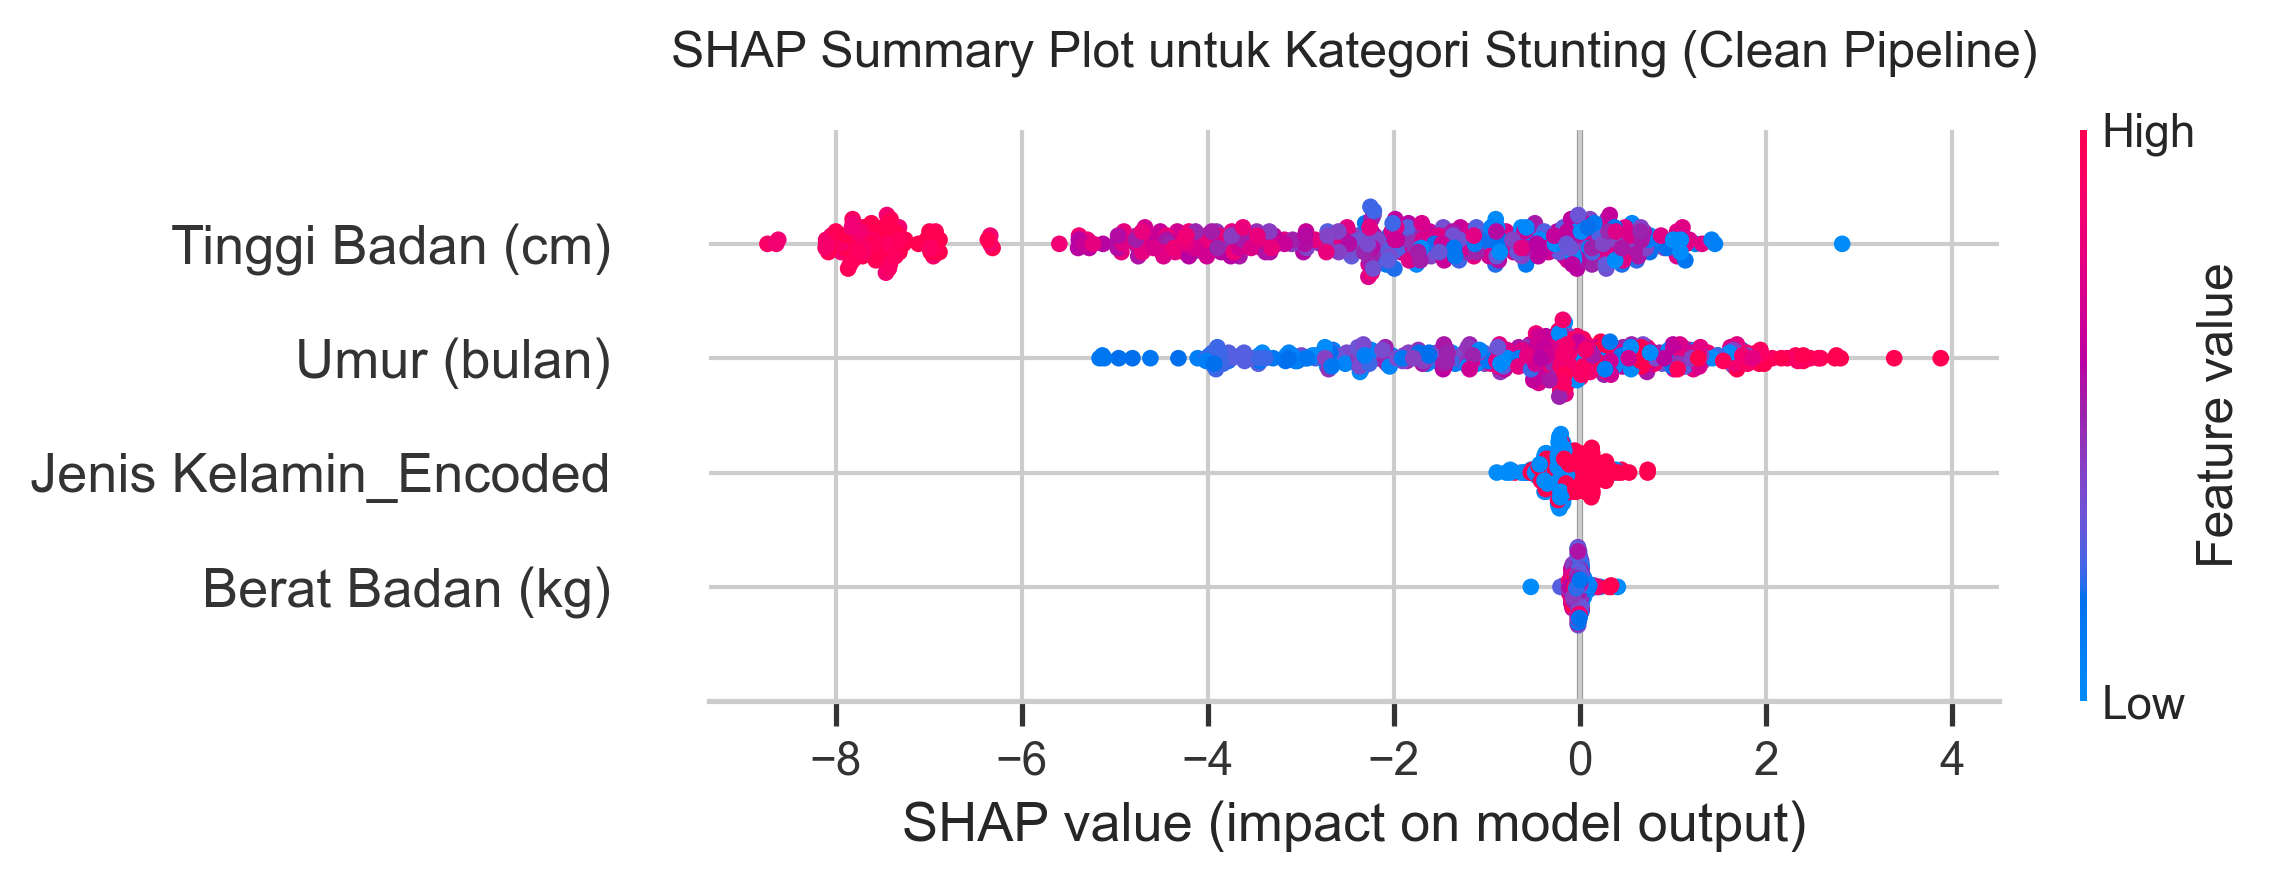

In [17]:
explainer = shap.TreeExplainer(best_model)
X_sample = X_test_c.sample(500, random_state=42)
shap_values = explainer(X_sample)

stunted_idx = list(stunting_encoder.classes_).index('Stunted')
print(f"Indeks kelas Stunted: {stunted_idx}")

# Global Summary Plot untuk kelas Stunted
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values[:, :, stunted_idx], X_sample, show=False)
plt.title('SHAP Summary Plot untuk Kategori Stunting (Clean Pipeline)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/shap_summary_classification.png', dpi=300, bbox_inches='tight')
plt.show()

### 9.1 Diagnosa Lokal Spesifik Anak A (SHAP Waterfall Plot)
Penjelasan rinci mengapa satu balita didiagnosis mengalami status gizi buruk stunting.

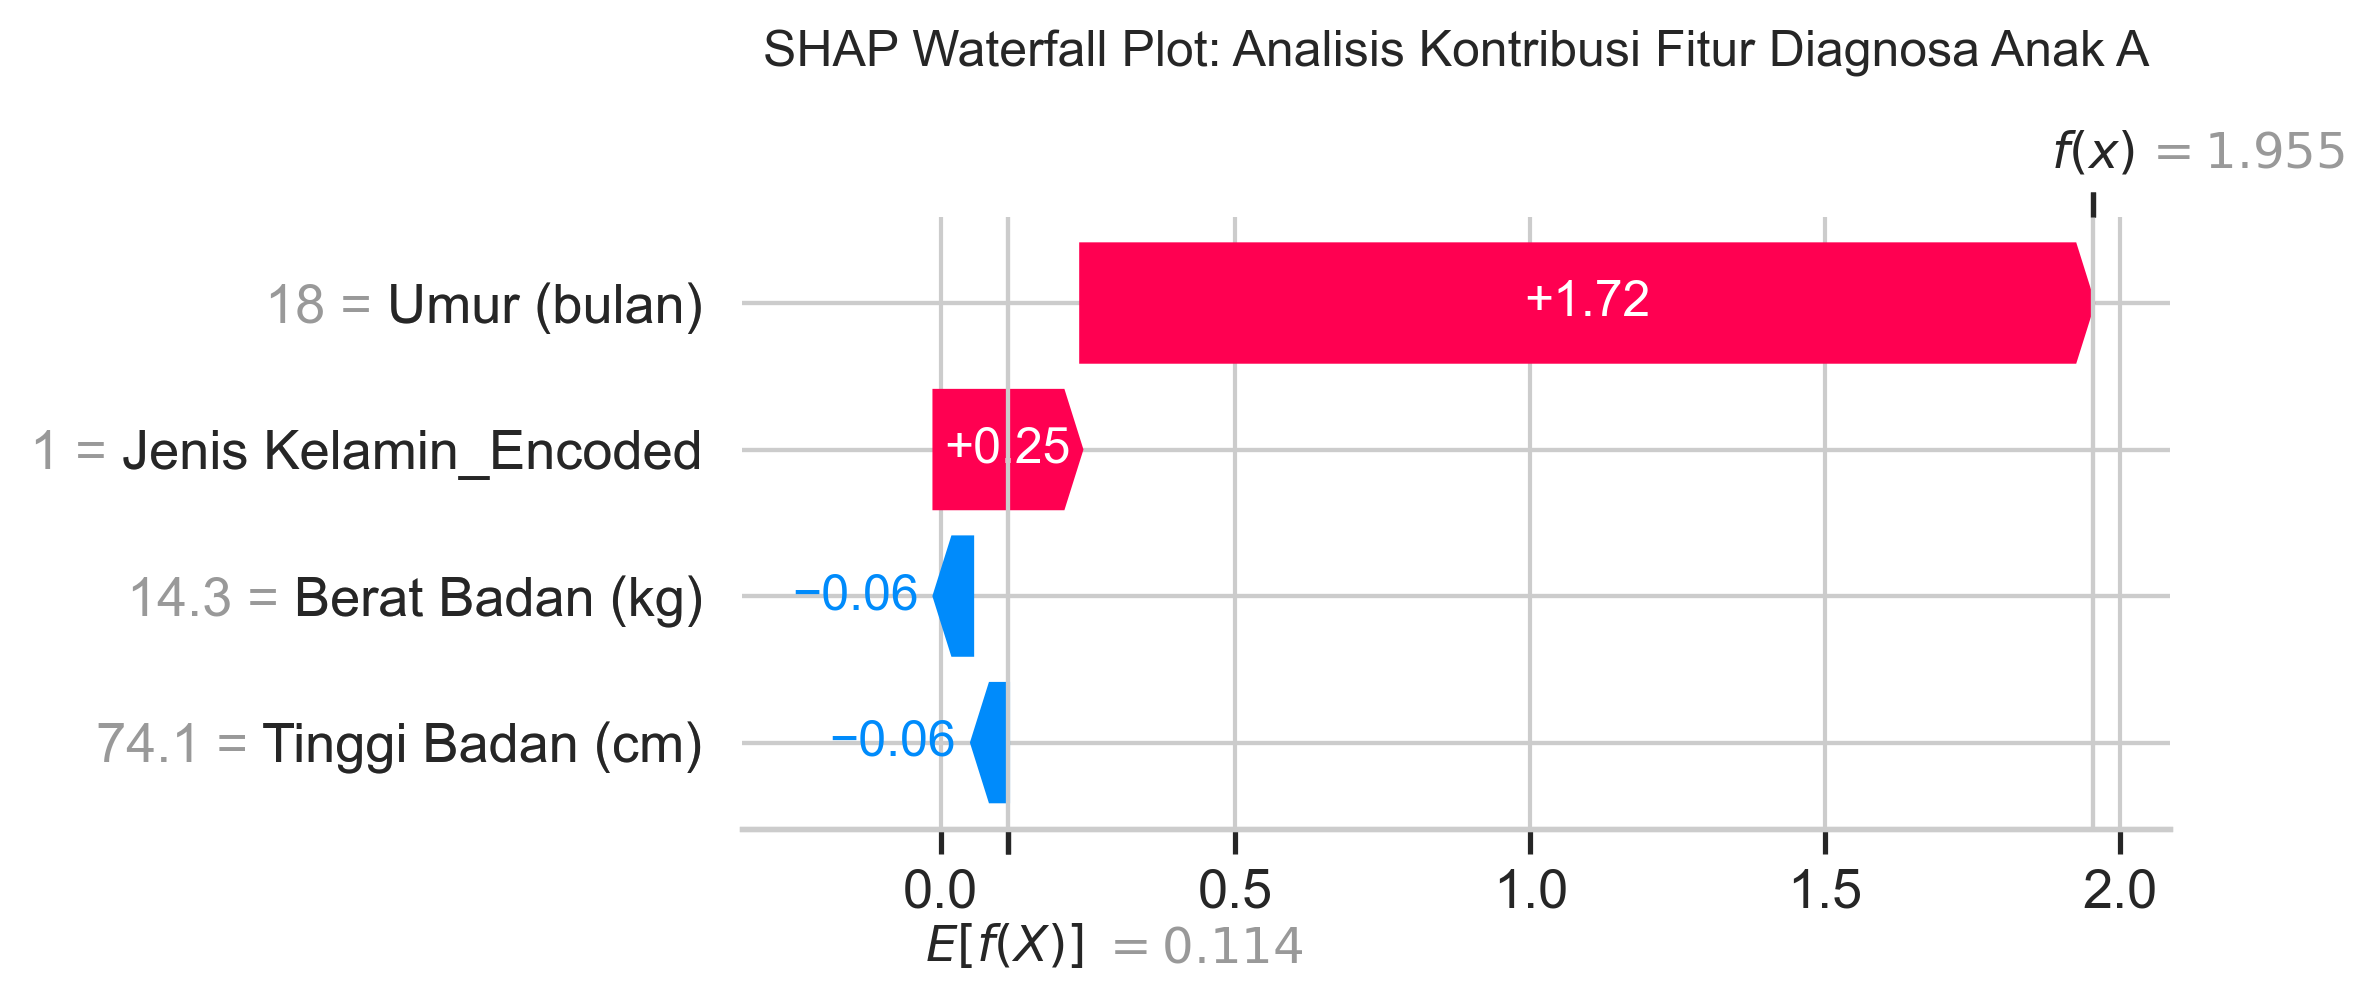

In [18]:
# Memilih sampel anak pertama yang terprediksi Stunted
stunted_samples = X_test_c[clean_preds == stunted_idx]
if len(stunted_samples) > 0:
    idx_sample = stunted_samples.index[0]
    single_sample = X_test_c.loc[[idx_sample]]
    single_shap = explainer(single_sample)

    # Konstruksi objek penjelasan SHAP untuk kelas Stunted
    exp = shap.Explanation(
        values=single_shap.values[0, :, stunted_idx],
        base_values=single_shap.base_values[0, stunted_idx] if hasattr(single_shap.base_values, '__len__') else single_shap.base_values,
        data=single_sample.iloc[0].values,
        feature_names=X_clean.columns.tolist()
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, show=False)
    plt.title('SHAP Waterfall Plot: Analisis Kontribusi Fitur Diagnosa Anak A', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('results/shap_waterfall_classification.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Tidak ada sampel stunted yang ditemukan untuk visualisasi waterfall.")

## 10. Model Serialization & Pipa Inferensi Produksi (MLOps)
Menyimpan model final terlatih ke disk dan menyediakan fungsi inferensi dengan validasi data fisik biologis anak.

In [19]:
# Menyimpan model dan encoder
joblib.dump(best_model, 'results/stunting_xgb_classifier.joblib')
joblib.dump(stunting_encoder, 'results/stunting_target_encoder.joblib')
joblib.dump(gender_encoder, 'results/stunting_gender_encoder.joblib')
print("Model dan encoder sukses disimpan di folder results/!")

# Pipa Inferensi Mandiri dengan Proteksi GIGO
def diagnosa_balita(jenis_kelamin, umur_bulan, tinggi_cm, berat_kg):
    # 1. Proteksi batas biologis input
    if not (0 <= umur_bulan <= 60):
        raise ValueError("Umur balita harus dalam rentang biologis 0 - 60 bulan.")
    if not (30 <= tinggi_cm <= 120):
        raise ValueError("Tinggi badan harus dalam rentang biologis 30 - 120 cm.")
    if not (2 <= berat_kg <= 30):
        raise ValueError("Berat badan harus dalam rentang biologis 2 - 30 kg.")
    if jenis_kelamin not in ['Laki-laki', 'Perempuan']:
        raise ValueError("Jenis kelamin harus 'Laki-laki' atau 'Perempuan'.")

    # 2. Transformasi input
    gender_enc = gender_encoder.transform([jenis_kelamin])[0]
    input_data = pd.DataFrame([{
        'Jenis Kelamin_Encoded': gender_enc,
        'Umur (bulan)': umur_bulan,
        'Tinggi Badan (cm)': tinggi_cm,
        'Berat Badan (kg)': berat_kg
    }])

    # 3. Prediksi
    pred_idx = best_model.predict(input_data)[0]
    pred_class = stunting_encoder.inverse_transform([pred_idx])[0]
    pred_proba = best_model.predict_proba(input_data)[0]
    confidence = pred_proba[pred_idx] * 100

    return pred_class, confidence

# Contoh pengujian inferensi baru
status, conf = diagnosa_balita(jenis_kelamin='Laki-laki', umur_bulan=18, tinggi_cm=70.5, berat_kg=8.5)
print(f"Hasil Diagnosis Anak Uji: {status} (Tingkat Keyakinan: {conf:.2f}%)")

Model dan encoder sukses disimpan di folder results/!
Hasil Diagnosis Anak Uji: Severely Stunted (Tingkat Keyakinan: 100.00%)
